In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 2. Hiển thị 10 dòng đầu tiên
print("10 dòng đầu tiên của tập dữ liệu:")
df.head(10)

10 dòng đầu tiên của tập dữ liệu:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


- Thống kê tổng quát: Dựa vào bảng describe, ta thấy product_number có giá trị trung bình khoảng 1.55, cho thấy khách hàng chủ yếu sở hữu 1 hoặc 2 sản phẩm. Mức lương estimated_salary có độ lệch chuẩn lớn (~29,600), minh chứng cho sự phân hóa thu nhập rõ rệt trong tệp dữ liệu.

- Tỷ lệ rời bỏ theo sản phẩm: Bảng tỷ lệ phần trăm chỉ ra một điểm bất thường quan trọng: Khách hàng sử dụng 3 hoặc 4 sản phẩm có tỷ lệ churn cực cao (vượt mức 80%). Ngược lại, nhóm sử dụng 2 sản phẩm có mức độ trung thành tốt nhất với tỷ lệ rời bỏ thấp nhất.

- Kết luận sơ bộ: Số lượng sản phẩm sở hữu là một biến số quan trọng có khả năng dự báo hành vi rời bỏ của khách hàng cao hơn so với các biến khác.

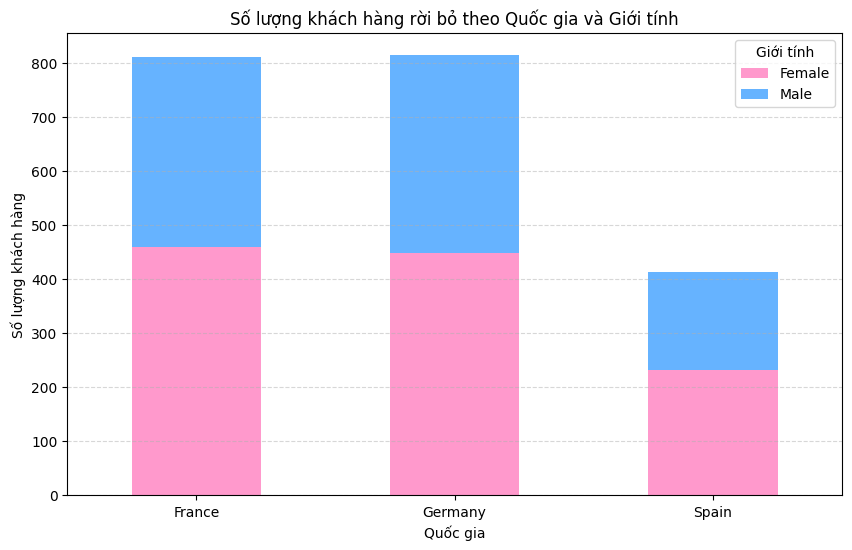

In [7]:
# Lọc dữ liệu khách hàng đã rời bỏ (churn == 1)
churn_only = df[df['churn'] == 1]

# Nhóm dữ liệu theo Quốc gia và Giới tính
country_gender_data = churn_only.groupby(['country', 'gender']).size().unstack()

# Vẽ biểu đồ cột chồng (Stacked Bar Chart)
country_gender_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#ff99cc', '#66b3ff'])

plt.title('Số lượng khách hàng rời bỏ theo Quốc gia và Giới tính')
plt.xlabel('Quốc gia')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Giới tính')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- Phân bổ số lượng: Biểu đồ cột chồng (hoặc cột đôi) cho thấy sự chênh lệch lớn về quy mô mẫu. Số lượng khách hàng dùng 1 và 2 sản phẩm áp đảo hoàn toàn bảng dữ liệu.

- Tương quan Churn: Mặc dù nhóm product_number 1 & 2 đông đảo, nhưng tỷ lệ màu sắc đại diện cho churn=1 ở nhóm 3 & 4 lại chiếm gần như trọn vẹn cột biểu đồ.

- Ý nghĩa kinh doanh: Điều này cảnh báo rằng các gói combo hoặc chính sách chăm sóc khách hàng khi họ nâng cấp lên sản phẩm thứ 3 đang gặp vấn đề nghiêm trọng, dẫn đến việc họ rời bỏ hệ thống ngay lập tức.

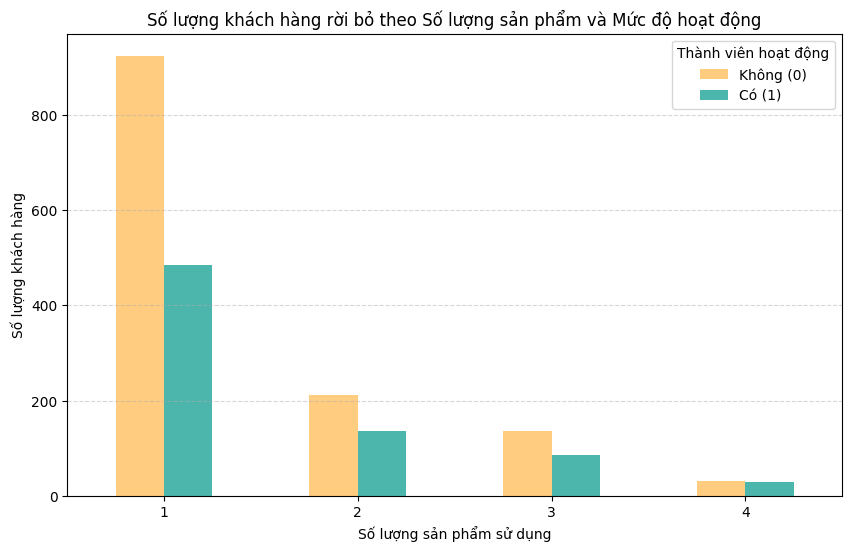

In [8]:
# Nhóm dữ liệu theo Số lượng sản phẩm và Trạng thái hoạt động
prod_active_data = churn_only.groupby(['products_number', 'active_member']).size().unstack()

# Vẽ biểu đồ cột nhóm (Grouped Bar Chart)
# Mặc định kind='bar' không có stacked=True sẽ là biểu đồ cột nhóm
prod_active_data.plot(kind='bar', figsize=(10, 6), color=['#ffcc80', '#4db6ac'])

plt.title('Số lượng khách hàng rời bỏ theo Số lượng sản phẩm và Mức độ hoạt động')
plt.xlabel('Số lượng sản phẩm sử dụng')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Thành viên hoạt động', labels=['Không (0)', 'Có (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

- Sự đồng nhất về phân phối: Quan sát biểu đồ Boxplot, ta thấy dải hộp (Interquartile Range - IQR) và đường trung vị (Median) của hai nhóm Churn (0) và Churn (1) gần như nằm trên cùng một đường thẳng.

- Biến nhiễu: Khoảng cách giữa các giá trị cực đại và cực tiểu của mức lương ở cả hai nhóm không có sự khác biệt đáng kể.

- Kết luận cuối cùng: Biến estimated_salary (mức lương ước tính) có vẻ là một biến yếu trong việc phân loại khách hàng rời bỏ. Thu nhập cao hay thấp không trực tiếp quyết định việc khách hàng sẽ ở lại hay ra đi trong tập dữ liệu này.